<a href="https://colab.research.google.com/github/Sayandt-web/CODSOFT/blob/main/DataScienceItern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.TITANIC SURVIVAL PREDICTION

Saving Titanic-Dataset.csv to Titanic-Dataset (3).csv
First 5 Rows of Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  5

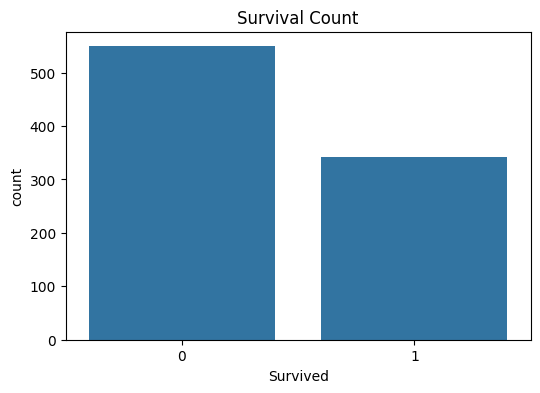

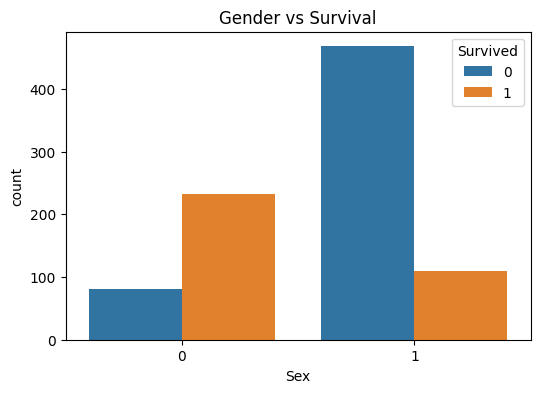

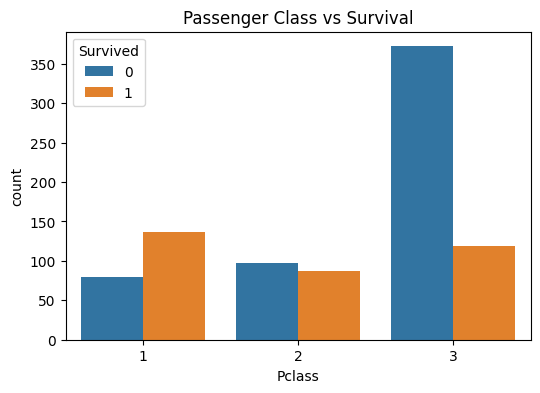


The passenger would NOT Survive.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression



from google.colab import files
uploaded = files.upload()


df = pd.read_csv('/content/Titanic-Dataset.csv')


print("First 5 Rows of Dataset:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)


age_imputer = SimpleImputer(strategy='median')
df['Age'] = age_imputer.fit_transform(df[['Age']])


embarked_imputer = SimpleImputer(strategy='most_frequent')
df['Embarked'] = embarked_imputer.fit_transform(df[['Embarked']]).ravel()



label_encoder = LabelEncoder()

df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['Embarked'] = label_encoder.fit_transform(df['Embarked'])



X = df.drop('Survived', axis=1)
y = df['Survived']



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)



y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()


plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()


plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

# Step 12: Predict for New Passenger

# Example Input:
# Pclass, Sex, Age, SibSp, Parch, Fare, Embarked

new_passenger = np.array([[3, 1, 22, 1, 0, 7.25, 2]])

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("\nThe passenger would Survive.")
else:
    print("\nThe passenger would NOT Survive.")

2.MOVIE RATING PREDICTION WITH PYTHON

Saving IMDb Movies India.csv to IMDb Movies India (2).csv
First 5 Rows:
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhati

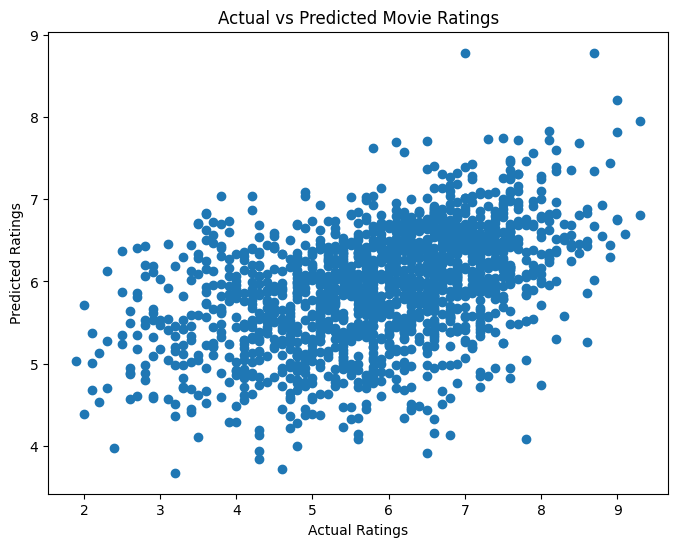

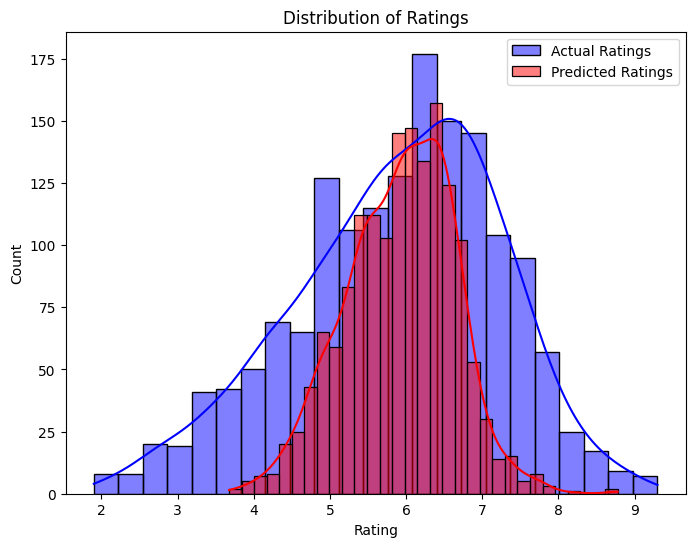


Predicted Movie Rating: 5.7


In [6]:
# Movie Rating Prediction using Machine Learning
# Run this complete code in Google Colab

# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Step 2: Upload Dataset in Google Colab

from google.colab import files
uploaded = files.upload()

# Step 3: Load Dataset

df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')

# Step 4: Display Basic Information

print("First 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Step 5: Data Cleaning

# Remove rows where Rating is missing
df = df.dropna(subset=['Rating'])

# Keep only useful columns
columns_needed = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Rating']

df = df[columns_needed]

# Fill missing values with empty strings
df.fillna('', inplace=True)

# Step 6: Combine Text Features

df['Combined_Features'] = (
    df['Genre'] + ' ' +
    df['Director'] + ' ' +
    df['Actor 1'] + ' ' +
    df['Actor 2'] + ' ' +
    df['Actor 3']
)

# Step 7: Define Features and Target

X = df['Combined_Features']
y = df['Rating']

# Step 8: Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 9: Convert Text Data into Numerical Form using TF-IDF

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Step 10: Train Machine Learning Model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

# Step 11: Make Predictions

y_pred = model.predict(X_test_tfidf)

# Step 12: Evaluate Model

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# Step 13: Compare Actual vs Predicted Ratings

comparison = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})

print("\nActual vs Predicted Ratings:")
print(comparison.head(10))

# Step 14: Visualization

# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")
plt.show()

# Distribution Plot
plt.figure(figsize=(8,6))
sns.histplot(y_test, color='blue', label='Actual Ratings', kde=True)
sns.histplot(y_pred, color='red', label='Predicted Ratings', kde=True)

plt.legend()
plt.title("Distribution of Ratings")
plt.show()

# Step 15: Predict Rating for a New Movie

new_movie = [
    "Action Drama Christopher Nolan Leonardo DiCaprio Joseph Gordon-Levitt Ellen Page"
]

new_movie_tfidf = tfidf.transform(new_movie)

predicted_rating = model.predict(new_movie_tfidf)

print("\nPredicted Movie Rating:", round(predicted_rating[0], 2))

3.IRIS FLOWER CLASSIFICATION

Saving IRIS.csv to IRIS (1).csv
First 5 Rows of Dataset:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing Values:
sepal_length    0
sepal_widt

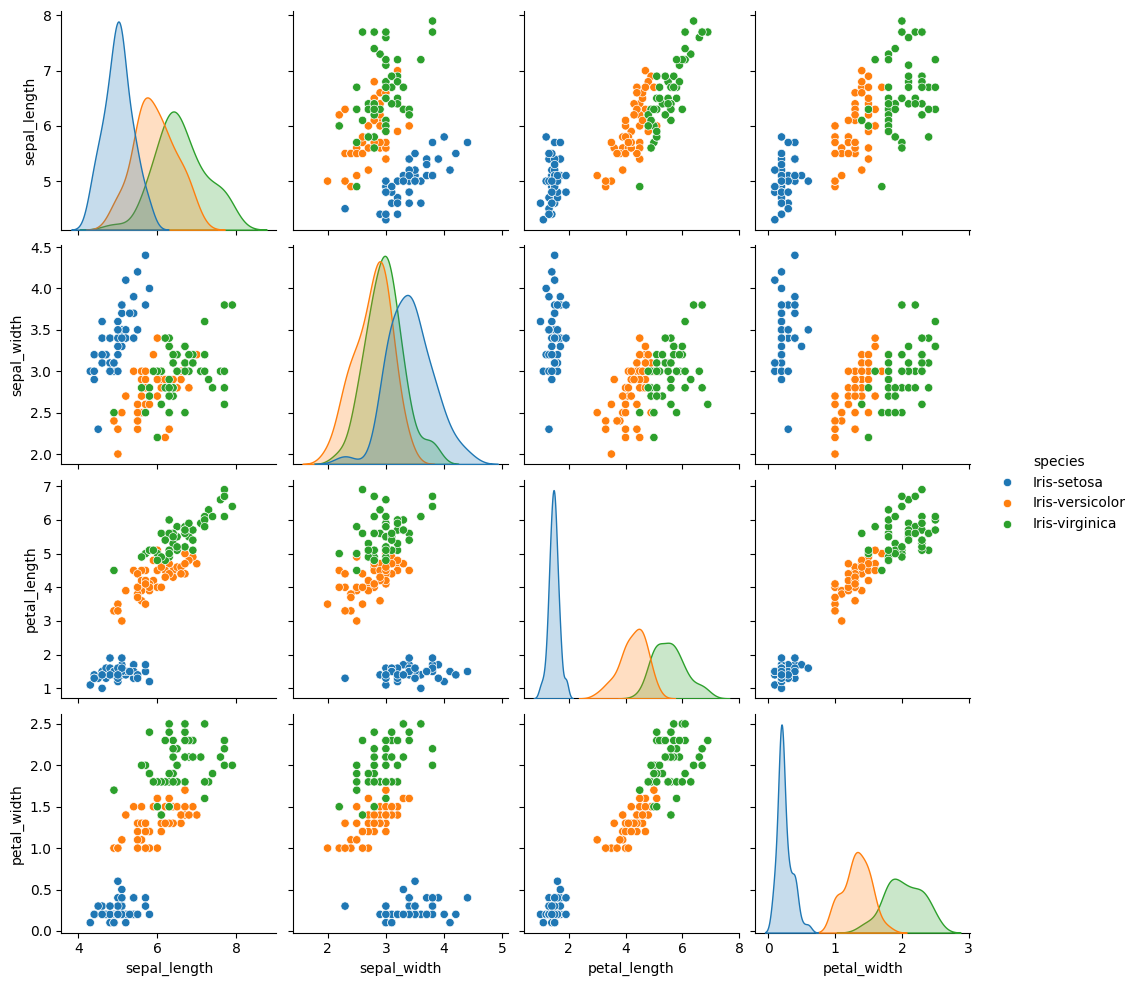

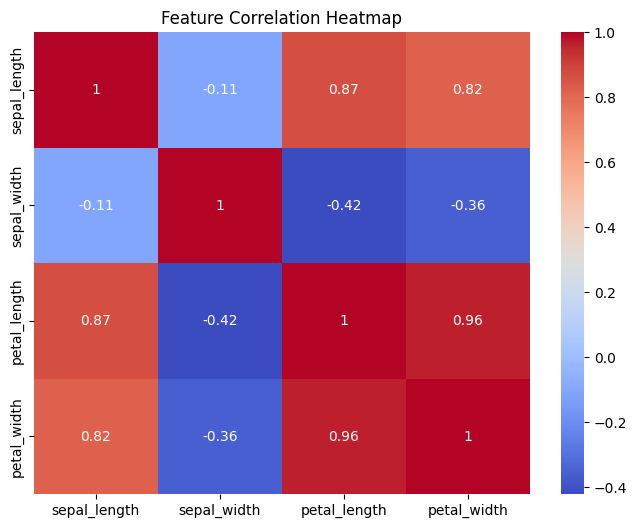


Model Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


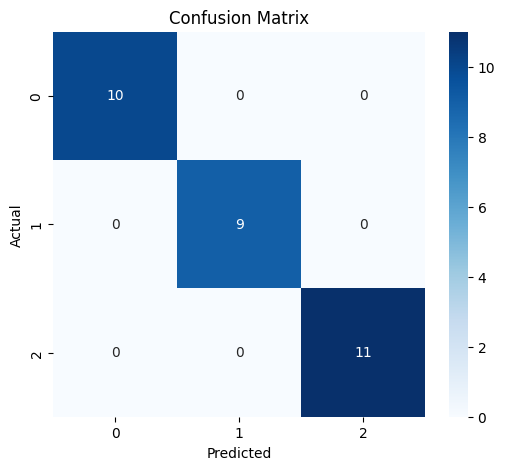


Predicted Iris Species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [7]:
# Iris Flower Classification using Machine Learning
# Run this complete code in Google Colab

# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

# Step 2: Upload Dataset in Google Colab

from google.colab import files
uploaded = files.upload()

# Step 3: Load Dataset

df = pd.read_csv("IRIS.csv")

# Step 4: Display Dataset Information

print("First 5 Rows of Dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Step 5: Data Visualization

# Pairplot
sns.pairplot(df, hue='species')
plt.show()

# Correlation Heatmap

plt.figure(figsize=(8,6))

numeric_df = df.drop('species', axis=1)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

# Step 6: Encode Target Labels

label_encoder = LabelEncoder()

df['species'] = label_encoder.fit_transform(df['species'])

# Step 7: Define Features and Target

X = df.drop('species', axis=1)
y = df['species']

# Step 8: Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 9: Train Machine Learning Model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Step 10: Make Predictions

y_pred = model.predict(X_test)

# Step 11: Evaluate Model

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Step 12: Visualize Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 13: Predict Species for New Flower

# Example Input:
# sepal_length, sepal_width, petal_length, petal_width

new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

prediction = model.predict(new_flower)

species_name = label_encoder.inverse_transform(prediction)

print("\nPredicted Iris Species:", species_name[0])